### All imported librairies and use

In [ ]:
import os #lets Python interact with your computer’s operating system.

import pandas as pd #main tool for data analysis and manipulation in Python - Reading datasets/Managing DataFrames/Cleaning, transforming, and analyzing data efficiently

import matplotlib.pyplot as plt #create visualizations — such as bar charts, line graphs, scatter plots, histograms, etc.
from scipy.io import arff


Import NSL-KDD dataset from Kaggle folder:

In [4]:
# List files in the local 'data' folder
print(os.listdir('data'))

# Paths to your training/test datasets
train_path = 'data/KDDTrain+.arff'
test_path  = 'data/KDDTest+.arff'

['KDDTest+.arff', 'KDDTrain+.arff']


In [5]:

# Function to read .arff files (skip metadata header) ---
# Since the NSL-KDD files contain ARFF headers that can cause parsing issues we created
# this function to extract only the data part (after '@data') and load it as CSV into Pandas.
def load_arff_as_csv(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Find where @data starts
    start = next(i for i, line in enumerate(lines) if line.strip().lower() == '@data') + 1

    # Read only the data portion
    data = lines[start:]

    # Save temporary CSV
    tmp_path = './temp.csv'
    with open(tmp_path, 'w') as f:
        f.writelines(data)

    # Load into pandas
    df = pd.read_csv(tmp_path, header=None)
    return df

# Load both datasets
df_train = load_arff_as_csv(train_path)
df_test = load_arff_as_csv(test_path)


# Quick Confirmation of Dataset import
print(df_train.head(5))

   0    1         2   3    4     5   6   7   8   9   ...   32    33    34  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...   25  0.17  0.03   
1   0  udp     other  SF  146     0   0   0   0   0  ...    1  0.00  0.60   
2   0  tcp   private  S0    0     0   0   0   0   0  ...   26  0.10  0.05   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  255  1.00  0.00   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  255  1.00  0.00   

     35    36    37    38    39    40       41  
0  0.17  0.00  0.00  0.00  0.05  0.00   normal  
1  0.88  0.00  0.00  0.00  0.00  0.00   normal  
2  0.00  0.00  1.00  1.00  0.00  0.00  anomaly  
3  0.03  0.04  0.03  0.01  0.00  0.01   normal  
4  0.00  0.00  0.00  0.00  0.00  0.00   normal  

[5 rows x 42 columns]


## Data Inspection

Inspect rows, columns, types, and class balance.

In [6]:
# Basic structure overview
print("Training set shape:", df_train.shape)
print("Test set shape:", df_test.shape)

# Number of rows and columns
n_rows, n_cols = df_train.shape
print(f"\n The training dataset contains {n_rows} rows and {n_cols} columns.")

# Column overview
print("\n Column names:")
print(df_train.columns.tolist())
# Initially, columns are unnamed (0–41) so we assign
#the official NSL-KDD feature names as follows :
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'
]

df_train.columns = columns
df_test.columns = columns

print("\n Column names assigned successfully:")
print(df_train.columns.tolist())

Training set shape: (125973, 42)
Test set shape: (22544, 42)

 The training dataset contains 125973 rows and 42 columns.

 Column names:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]

 Column names assigned successfully:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_ser


 Data types summary:
int64      23
float64    15
object      4
Name: count, dtype: int64

 Statistical summary (numeric features):
                      count          mean           std  min  25%   50%  \
duration           125973.0    287.144650  2.604515e+03  0.0  0.0   0.0   
src_bytes          125973.0  45566.743000  5.870331e+06  0.0  0.0  44.0   
dst_bytes          125973.0  19779.114421  4.021269e+06  0.0  0.0   0.0   
land               125973.0      0.000198  1.408607e-02  0.0  0.0   0.0   
wrong_fragment     125973.0      0.022687  2.535300e-01  0.0  0.0   0.0   
urgent             125973.0      0.000111  1.436603e-02  0.0  0.0   0.0   
hot                125973.0      0.204409  2.149968e+00  0.0  0.0   0.0   
num_failed_logins  125973.0      0.001222  4.523914e-02  0.0  0.0   0.0   
logged_in          125973.0      0.395736  4.890101e-01  0.0  0.0   0.0   
num_compromised    125973.0      0.279250  2.394204e+01  0.0  0.0   0.0   

                     75%           max  
d

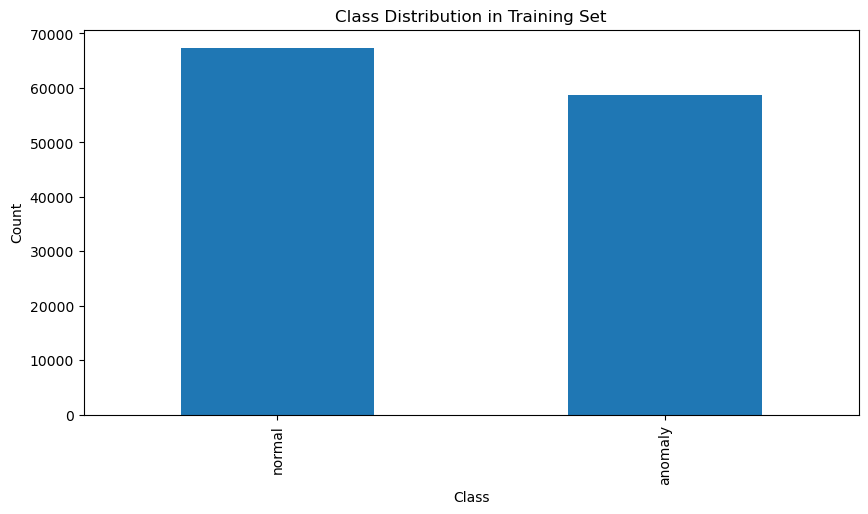

In [7]:
# Data types and quick info
print("\n Data types summary:")
print(df_train.dtypes.value_counts())

# Summary of numeric columns
print("\n Statistical summary (numeric features):")
print(df_train.describe().T.head(10))

# Check for missing values
print("\n Missing values per column:")
print(df_train.isnull().sum().sort_values(ascending=False).head())

# Check unique values for key categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    if col in df_train.columns:
        print(f"\n Unique values in '{col}': {df_train[col].nunique()} → {df_train[col].unique()[:10]}")

# Class balance (target distribution)
print("\n Class distribution in training data:")
print(df_train['label'].value_counts())
print("\nClass distribution (%)")
print(round(df_train['label'].value_counts(normalize=True) * 100, 2))

#Visual class balance
df_train['label'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


In [8]:
df_train.shape, df_test.shape


((125973, 42), (22544, 42))